In [1]:
import keras
import tensorflow as tf
print(f"Keras:      {keras.__version__}")
print(f"TensorFlow: {tf.__version__}")

I0000 00:00:1774409836.449860  868927 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774409836.499410  868927 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774409838.657959  868927 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras:      3.13.2
TensorFlow: 2.21.0


In [53]:
%cd /scratch/saifur/zheng_encoder/scripts
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["KERAS_BACKEND"]                 = "jax"

import logging
import argparse
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import data
import model
import evaluate
import config

importlib.reload(data)
importlib.reload(model)
importlib.reload(evaluate)
importlib.reload(config)

from data     import (sample_for_training, load_and_save_parquet, load_parquet,
                         encode_features, save_xtrain, load_xtrain, free_memory)
from model    import (build_vae, train_vae,
                       get_bottleneck, save_model)
from evaluate import (check_bottleneck_normality,
                       plot_training_history,
                       plot_compressed_distribution,
                       plot_scatter)
import config
%cd ..

/scratch/saifur/zheng_encoder/scripts
/scratch/saifur/zheng_encoder


In [3]:
# ── Logging setup ─────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = '%(asctime)s | %(levelname)s | %(name)s | %(message)s',
    handlers = [
        logging.StreamHandler(),
        logging.FileHandler('pipeline.log')
    ]
)
log = logging.getLogger(__name__)

In [4]:
def step_preprocess(skip_csv: bool = False):
    """Step 1: Load raw data → clean → save parquet"""
    log.info("=" * 50)
    log.info("STEP 1: Preprocessing")
    log.info("=" * 50)

    if not skip_csv:
        load_and_save_parquet(
            raw_path    = config.RAW_INPUT,
            parquet_path = config.PARQUET_PATH,
            na_rows_path = config.NA_ROWS_PATH
        )

    df = load_parquet(config.PARQUET_PATH)

    return df

In [5]:
def step_encode(df: pd.DataFrame, skip_encode: bool = False):
    """Step 2: Encode features → X_train matrix"""
    log.info("=" * 50)
    log.info("STEP 2: Feature encoding")
    log.info("=" * 50)

    if skip_encode:
        X_train = load_xtrain(config.XTRAIN_PATH)
        return X_train, df

    X_train, scaler = encode_features(df)
    save_xtrain(X_train, config.XTRAIN_PATH)

    # Free df memory — no longer needed after encoding
    free_memory(df)

    return X_train, scaler

In [6]:
def step_train(X_train: np.ndarray,
               beta:    float = None,
               epochs:  int   = None,
               skip_train: bool = False):
    """Step 3: Build and train VAE"""
    log.info("=" * 50)
    log.info("STEP 3: VAE Training")
    log.info("=" * 50)

    beta   = beta   or config.BETA
    epochs = epochs or config.EPOCHS

    vae, encoder, decoder = build_vae(
        input_dim  = config.INPUT_DIM,
        latent_dim = config.LATENT_DIM,
        hidden_dim = config.HIDDEN_DIM,
        beta       = beta
    )

    if skip_train:
        log.info("Loading saved encoder...")
        from model import load_encoder
        encoder = load_encoder("vae_encoder.keras")
        return None, encoder, None, None

    vae.summary()

    history = train_vae(
        vae              = vae,
        X_train          = X_train,
        epochs           = epochs,
        batch_size       = config.BATCH_SIZE,
        validation_split = config.VALIDATION_SPLIT,
        early_stop_patience = config.EARLY_STOP_PATIENCE,
        reduce_lr_patience  = config.REDUCE_LR_PATIENCE,
        reduce_lr_factor    = config.REDUCE_LR_FACTOR,
        min_lr              = config.MIN_LR
    )

    save_model(vae, encoder, decoder, prefix="vae")
    plot_training_history(history,
                          save_path='figs/training_history.png')

    return vae, encoder, decoder, history


In [7]:
def step_infer(encoder,
               X_test:  np.ndarray,
               df_orig:  pd.DataFrame = None):
    """Step 4: Extract bottleneck → save results"""
    log.info("=" * 50)
    log.info("STEP 4: Inference")
    log.info("=" * 50)

    z_mean_vals, z_log_var_vals, z_sampled = get_bottleneck(
        encoder    = encoder,
        X          = X_test,
        batch_size = config.PREDICT_BATCH_SIZE
    )

    # Normality check
    # check_bottleneck_normality(
    #     z_mean_vals = z_mean_vals,
    #     z_sampled   = z_sampled,
    #     save_path   = 'figs/bottleneck_normality.png'
    # )

    # Attach compressed values to original dataframe
    if df_orig is not None:
        df_orig['compressed_1D'] = z_sampled.flatten()
        
        # Plots
        plot_compressed_distribution(
            df        = df_orig,
            col       = 'compressed_1D',
            group_col = 'present',
            save_path = 'figs/compressed_distribution.png'
        )
        plot_scatter(
            df        = df_orig,
            x_col     = 'expression',
            y_col     = 'compressed_1D',
            group_col = 'present',
            save_path = 'figs/scatter_expression_vs_compressed.png'
        )

        # Save output
        # log.info("Saving inferred results...")
        # df_orig.to_parquet(config.OUTPUT_PARQUET,
        #                     compression='snappy')
        # log.info(f"Saved results → {config.OUTPUT_PARQUET}")
        # # save as CSV for easy inspection
        # df_orig.to_csv("inferred_results.csv", index=False)
        # log.info(f"Saved results → inferred_results.csv")

        return df_orig

    return z_mean_vals, z_log_var_vals, z_sampled


In [46]:
df_full = step_preprocess(skip_csv=True)   
df_full.loc[df_full['present'] == 0, 'expression'] = -9.97

2026-03-24 22:53:57,881 | INFO | __main__ | ==================================================
2026-03-24 22:53:57,882 | INFO | __main__ | STEP 1: Preprocessing
2026-03-24 22:53:57,883 | INFO | __main__ | ==================================================
2026-03-24 22:53:57,883 | INFO | data | Loading parquet: data/input_filtered3_M2.parquet
2026-03-24 22:54:47,598 | INFO | data | Loaded 1,021,138,800 rows


In [24]:
df_full.loc[df_full['present'] == 0, 'expression'] = -9.97

In [47]:
 # Sample 1M rows for training
df_train_sample = sample_for_training(
    df          = df_full,
    n           = config.TRAIN_SAMPLE_SIZE,   # 1_000_000
    random_seed = config.RANDOM_SEED
)
# df_train_sample = df_train_sample[df_train_sample['expression'] >= -10]
log.info(f"Training sample: {len(df_train_sample):,} rows")

# Encode sample → X_train (1M rows)
log.info("Encoding training sample using NA value = %f...", config.NA_VALUE)
X_train, scaler = encode_features(df_train_sample, na_value=config.NA_VALUE)
# save_xtrain(X_train, config.XTRAIN_PATH)


2026-03-24 22:55:21,885 | INFO | data | Sampled 1,000,000 rows from 1,021,138,800 (stratified by present)
2026-03-24 22:55:21,891 | INFO | data | Sample value counts:
present
2    420343
0    394383
1    185274
2026-03-24 22:55:21,892 | INFO | __main__ | Training sample: 1,000,000 rows
2026-03-24 22:55:21,893 | INFO | __main__ | Encoding training sample using NA value = -20.000000...
2026-03-24 22:55:21,931 | INFO | data | No Scaling applied to transformed columns...
2026-03-24 22:55:21,939 | INFO | data | X_train shape: (1000000, 3)
2026-03-24 22:55:21,940 | INFO | data | X_train dtype: float32


In [48]:
X_train

array([[-20.     , -20.     ,   1.78799],
       [-20.     , -20.     ,   4.32875],
       [-20.     , -20.     ,   3.76847],
       ...,
       [-20.     , -20.     ,   3.42214],
       [ -9.97   , -20.     , -20.     ],
       [ -9.97   , -20.     , -20.     ]],
      shape=(1000000, 3), dtype=float32)

In [41]:
df_full

,gene,sample,present,expression
0,>10000003>10000004:0:1:7:SNP,HG00097,0,-20.00000
1,>10000003>10000004:0:1:7:SNP,HG00099,0,-20.00000
2,>10000003>10000004:0:1:7:SNP,HG00126,0,-20.00000
3,>10000003>10000004:0:1:7:SNP,HG00128,0,-20.00000
4,>10000003>10000004:0:1:7:SNP,HG00133,0,-20.00000
...,...,...,...,...
1021138795,>9999967>9999968:153:1:425:SNP,NA21102,1,4.07834
1021138796,>9999967>9999968:153:1:425:SNP,NA21106,2,3.95995
1021138797,>9999967>9999968:153:1:425:SNP,NA21110,2,4.07834
1021138798,>9999967>9999968:153:1:425:SNP,NA21144,2,4.02466


2026-03-24 22:55:34,494 | INFO | __main__ | ==================================================
2026-03-24 22:55:34,495 | INFO | __main__ | STEP 3: VAE Training
2026-03-24 22:55:34,496 | INFO | __main__ | ==================================================
2026-03-24 22:55:34,534 | INFO | model | VAE built successfully
2026-03-24 22:55:34,535 | INFO | model |   input_dim=3, latent_dim=1, hidden_dim=32, beta=10


Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_hidden      │ (None, 32)        │        128 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 1)         │         33 │ encoder_hidden[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 1)         │         33 │ encoder_hidden[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (SamplingLayer)   │ (None, 1)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder             │ (None, 3)         │        163 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss (VAELoss)  │ (None, 3)         │          0 │ encoder_input[0]… │
│                     │                   │            │ Decoder[0][0],    │
│                     │                   │            │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 357 (1.39 KB)

 Trainable params: 357 (1.39 KB)

...

2026-03-24 22:55:34,542 | INFO | model | Training VAE: 1,000,000 samples, 3 epochs, batch_size=32


Epoch 1/3


I0000 00:00:1774410935.422348  869076 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1144272__.10


28125/28125 ━━━━━━━━━━━━━━━━━━━━ 26s 846us/step - loss: 45.6447 - val_loss: 22.7946 - learning_rate: 0.0010
Epoch 2/3
28125/28125 ━━━━━━━━━━━━━━━━━━━━ 21s 748us/step - loss: 22.3838 - val_loss: 22.0807 - learning_rate: 0.0010
Epoch 3/3
28125/28125 ━━━━━━━━━━━━━━━━━━━━ 22s 795us/step - loss: 22.0160 - val_loss: 21.9364 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.


2026-03-24 22:56:43,586 | INFO | model | Training complete — best epoch=3, val_loss=21.9364
2026-03-24 22:56:43,635 | INFO | model | Models saved with prefix 'vae'
2026-03-24 22:56:43,780 | INFO | evaluate | Saved training plot → figs/training_history.png


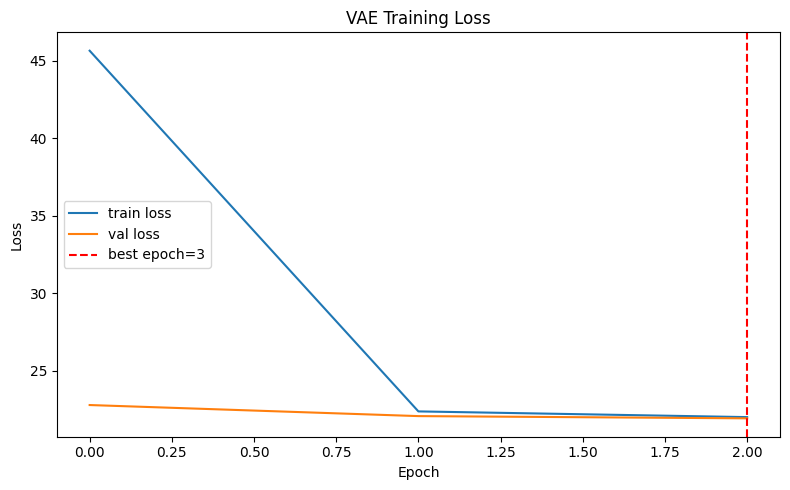

In [49]:
vae, encoder, decoder, history = step_train(
    X_train    = X_train,       # ← 1M rows only
    beta       = 10,
    epochs     = 3,
    skip_train = False
)

In [15]:

if config.INFER_ALL_ROWS:
    log.info(f"Encoding ALL {len(df_full):,} rows for inference...")
    df_infer = df_full
    # Encode full dataset using the same encoders
    X_full, _ = encode_features(df_infer, na_value=config.NA_VALUE, scaler=scaler)
    log.info(f"X_full shape: {X_full.shape}")
else:
    log.info("Skipping encoding of full dataset — using training sample for inference")
    X_full = X_train
    df_infer = df_train_sample

2026-03-23 23:26:44,602 | INFO | __main__ | Encoding ALL 1,021,138,800 rows for inference...
2026-03-23 23:26:44,603 | INFO | data | Encoding features...
2026-03-23 23:26:50,095 | INFO | data | Set expression=0 for 402,606,914 present=0 rows
2026-03-23 23:27:26,133 | INFO | data | No Scaling applied to transformed columns...
2026-03-23 23:27:40,081 | INFO | data | X_train shape: (1021138800, 3)
2026-03-23 23:27:40,083 | INFO | data | X_train dtype: float32
2026-03-23 23:27:40,136 | INFO | __main__ | X_full shape: (1021138800, 3)


In [50]:
X_full = X_train
df_infer = df_train_sample

2026-03-24 22:56:52,048 | INFO | __main__ | ==================================================
2026-03-24 22:56:52,049 | INFO | __main__ | STEP 4: Inference
2026-03-24 22:56:52,050 | INFO | __main__ | ==================================================
2026-03-24 22:56:52,051 | INFO | model | Extracting bottleneck for 1,000,000 samples...


123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


2026-03-24 22:56:53,096 | INFO | model | Bottleneck statistics:
2026-03-24 22:56:53,099 | INFO | model |   z_mean:    mean=-0.0399  std=0.9895  (ideal: 0, 1)
2026-03-24 22:56:53,101 | INFO | model |   z_sampled: mean=-0.0400  std=1.0161  (ideal: 0, 1)
2026-03-24 22:56:55,016 | INFO | evaluate | Saved distribution plot → figs/compressed_distribution.png


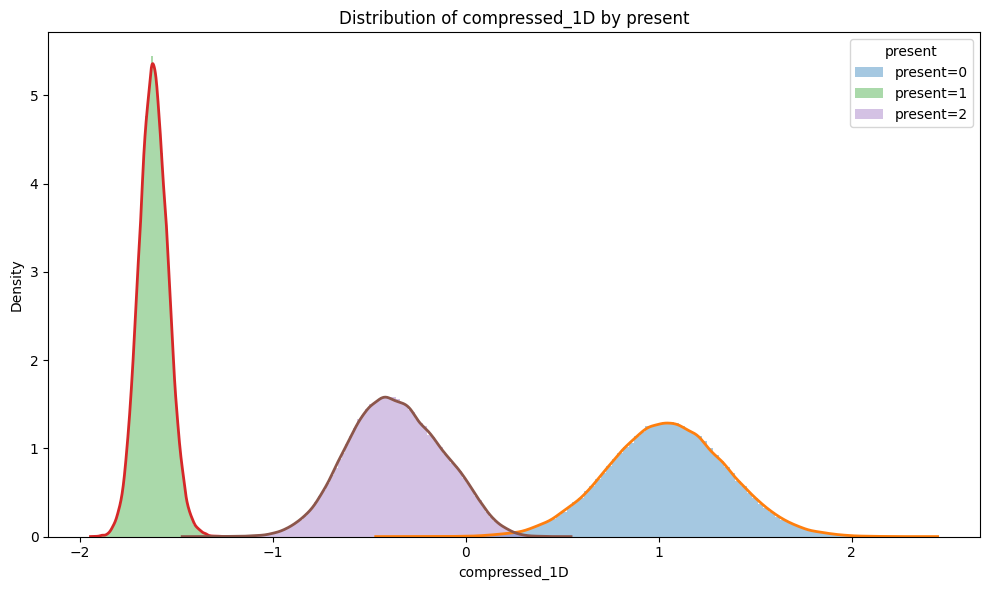

2026-03-24 22:56:57,014 | INFO | evaluate | Saved scatter plot → figs/scatter_expression_vs_compressed.png


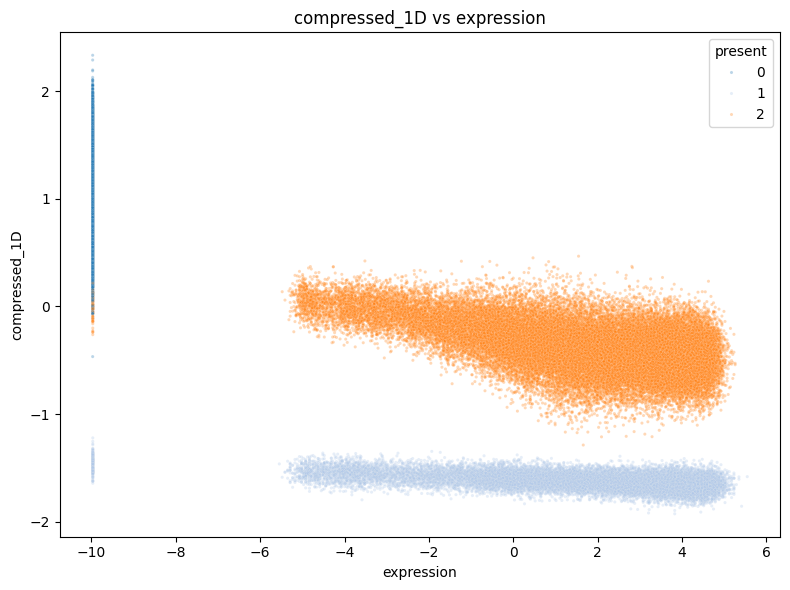

In [51]:
df_result = step_infer(
        encoder  = encoder,
        X_test  = X_full, 
        df_orig  = df_infer
    )

In [ ]:
kde_plot = df.hvplot.kde(
    y = 'expression',
    by='present',
    line_width=2,
    alpha=0.5
)
kde_plot

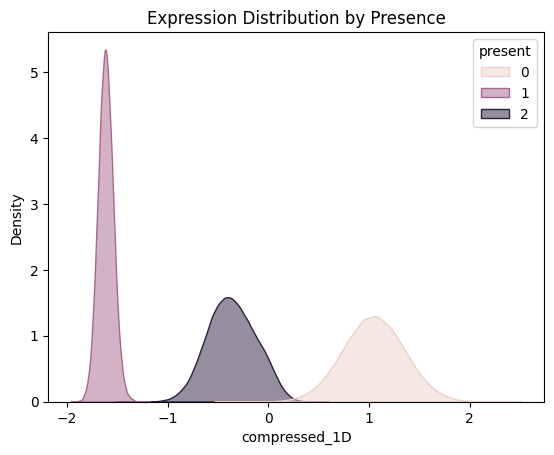

In [54]:
import seaborn as sns
sns.kdeplot(data=df_result, x='compressed_1D', hue='present', fill=True, alpha=0.5,common_norm=False)
plt.title("Expression Distribution by Presence")
plt.show()